In [1]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image

In [12]:
# CONTROLLO SE NUMERO MASCHERE E IMMAGINI COINCIDONO
%pwd

DATA_PATH = 'data/raw/monuseg'

os.listdir(DATA_PATH)

image_paths = (
    glob.glob(os.path.join(DATA_PATH, "kmms_training", "kmms_training", "images", "*.tif*")) +
    glob.glob(os.path.join(DATA_PATH, "kmms_test", "kmms_test", "images", "*.png*")) +
    glob.glob(os.path.join(DATA_PATH, "kmms_test", "kmms_test", "images", "*.tif*"))
)
mask_paths = glob.glob(os.path.join(DATA_PATH, "kmms_training", "kmms_training", "masks", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "kmms_test", "kmms_test", "masks", "*.png*"))



print(len(image_paths))
print(len(mask_paths))


82
82


In [13]:
# CONTROLLO SE MASCHERE BINARIE
# 1. maschera di esempio

percorso_test = mask_paths[2]
maschera = cv2.imread(percorso_test, cv2.IMREAD_UNCHANGED)

# 2. conotrollo valori unici
valori = np.unique(maschera)

print("--- ESITO DEL TEST ---")
print(f"I valori presenti nella maschera sono: {valori}")

# 3. Interpretazione automatica
if len(valori) == 2:
    print("Confermato: Il dataset è BINARIO (solo sfondo e nuclei).")
else:
    print(f"Il dataset è MULTICLASSE (contiene {len(valori)} tipi di etichette).") 

--- ESITO DEL TEST ---
I valori presenti nella maschera sono: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 2

In [18]:
print(maschera[:20, :20])

[[181 213 255 255 255 255 245 202 116   0   0   0   0   0   0   0   0   0
    0   0]
 [255 255 255 255 255 255 255 255 254  49   0   3   0   0   0   0   0   0
    0   0]
 [255 252 253 255 255 255 254 250 255  55   0   3   0   0   0   0   0   0
    0   0]
 [215 255 255 255 252 251 250 255 166   3   1   1   0   0   0   0   0   0
    0   0]
 [ 11  88 202 255 255 255 255 161   9   0   1   0   0   0   0   0   0   0
    0   0]
 [  0   0   5  54 150 166 114   1   0   1   0   0   0   0   0   0   0   0
    0   2]
 [  1   3   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0
    2   0]
 [  0   0   2   5   6   7   6   3   2   1   0   0   0   0   0   0   0   2
    0  71]
 [  0   0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   3   0
  100 249]
 [  1   0  28 132  81  69  74  64  32  16   0   1   0   0   0   1   0  20
  236 254]
 [  4   0 107 255 255 255 255 255 236 216  56   0   2   0   0   1   2   9
  167 255]
 [  1   0 170 250 249 253 252 254 255 255 222  17   1   1   0   0

In [21]:
def binarizza_mask(percorso):
    maschera = cv2.imread(percorso, cv2.IMREAD_UNCHANGED)

    # Otsu → trova soglia automaticamente
    _, mask_bin = cv2.threshold(
        maschera,
        0,
        1,  # output 0/1
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return mask_bin.astype(np.uint8)

mask_bin_paths = []

for path in mask_paths:
    mask_bin = binarizza_mask(path)

    # opzionale: salva su disco
    save_path = path.replace("masks", "masks_bin")
    cv2.imwrite(save_path, mask_bin * 255)

    mask_bin_paths.append(save_path)

In [22]:
# VERIFICA BINARIZZAZIONE
test = binarizza_mask(mask_paths[0])
print(np.unique(test))

[0 1]


In [23]:
# FUNZIONE UTILE PER ESTRARRE DATI DALLE IMMAGINI

def load_labels_from_png(mask_path):
    #Estrae metadati (inst_map, bboxes, centroids) da una maschera PNG binaria. crea una carta d'identità digitale per ogni singolo nucleo
    #IMREAD_GRAYSCALE serve a caricare l'immagine in scala di grigi.
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, inst_map, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    # SPIEGAZIONE DEI 4 RISULTATI:
    # 1. num_labels: Un numero intero(numero nuclei +1 (che è lo sfondo che ha indice 0)). Se trova 4 nuclei, sarà 5 (perché conta anche lo sfondo!).
    # 2. inst_map: Una matrice grande come l'immagine originale. Sfondo: Il computer inizia a leggere e vede il nero. Dice: "Ok, questo è lo 0". 
        #Primo Nucleo: Incontra la prima macchia bianca. Dice: "Tutti i pixel di questa macchia d'ora in poi si chiameranno 1".
        #Secondo Nucleo: Prosegue e trova un'altra macchia separata. Dice: "Questi pixel non sono attaccati all'1, quindi sono un nuovo oggetto. Li chiamerò 2"
        #np.where(inst_map == 2),  restituirà solo ed esclusivamente le coordinate del secondo nucleo
    # 3. stats: Una tabella con 5 colonne per ogni oggetto (x, y, larghezza, altezza, area). 
        #C'è un collegamento perfetto e biunivoco (uno a uno) tra il numero del nucleo e la riga della tabella stats
        #Se nella inst_map vedi un gruppo di pixel con il numero 2, tutte le informazioni fisiche di quel gruppo si trovano nella riga 2 della tabella stats
    # 4. centroids: Una tabella con le coordinate (x, y) del centro esatto di ogni oggetto.

    #lista per i nuclei, es. np.arrange(1, 5): [1, 2, 3, 4]
    nuclei_id = np.arange(1, num_labels) 
   
        # array di "1" lungo quanto la lista dei nuclei (dataset binario, classe nuclei=1)
    classes = np.ones(len(nuclei_id), dtype=int)


    #Calcolo delle Bounding Boxes (Rettangoli)
    #da [x, y, larghezza, altezza] a [x_min, y_min, x_max, y_max].

    bboxes = []
    for i in range(1, num_labels): # no 0
        x_min, y_min, width, height, area = stats[i]
        # Calcoliamo il punto d'angolo opposto
        x_max = x_min + width
        y_max = y_min + height
        # Aggiungiamo i 4 numeri alla nostra lista
        bboxes.append([x_min, y_min, x_max, y_max]) 
        # lista in una matrice NumPy (array) -> più veloce per i calcoli
    bboxes = np.array(bboxes)
# Pulizia dei Centroidi (centroids ha anche il centro dell'immagine, togliamo)
    final_centroids = centroids[1:]

#Creazione del Dizionario e INVIO (Return) ---
    dict_labels = {
        'inst_map': inst_map,         # La matrice con i numeri ID
        'nuclei_id': nuclei_id,       # La lista [1, 2, 3...]
        'classes': classes,           # La lista [1, 1, 1...]
        'bboxs': bboxes,              # I rettangoli [x_min, y_min, x_max, y_max]
        'centroids': final_centroids  # I punti centrali (x, y)
    }
    
    return dict_labels

In [24]:
# VERIFICA NUCLEI TORVATI NELLA PRIMA IMMAGINE
percorso_della_mia_maschera = mask_paths[0] 

label = load_labels_from_png(percorso_della_mia_maschera)
print("Informazioni disponibili:", label.keys()) 
# Estrai la matrice dei centroidi
centroids = label['centroids']

# Verifica quanti nuclei sono stati trovati
print(f"Numero di nuclei rilevati: {len(centroids)}") 



Informazioni disponibili: dict_keys(['inst_map', 'nuclei_id', 'classes', 'bboxs', 'centroids'])
Numero di nuclei rilevati: 223


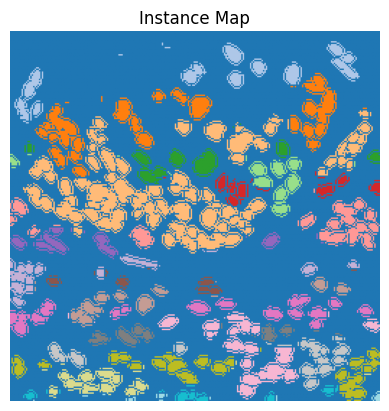

In [25]:
# ESEMPIO INSTANCE MASK, mappa colori categorica
inst_map = label['inst_map'] 
bboxs = label['bboxs']
nuclei_id = label['nuclei_id']
centroids = label['centroids']
classes = label ['classes']
# variabili singole più facili da manipolare

plt.imshow(inst_map, cmap="tab20") 
plt.title("Instance Map") 
plt.axis("off") 
plt.show() 

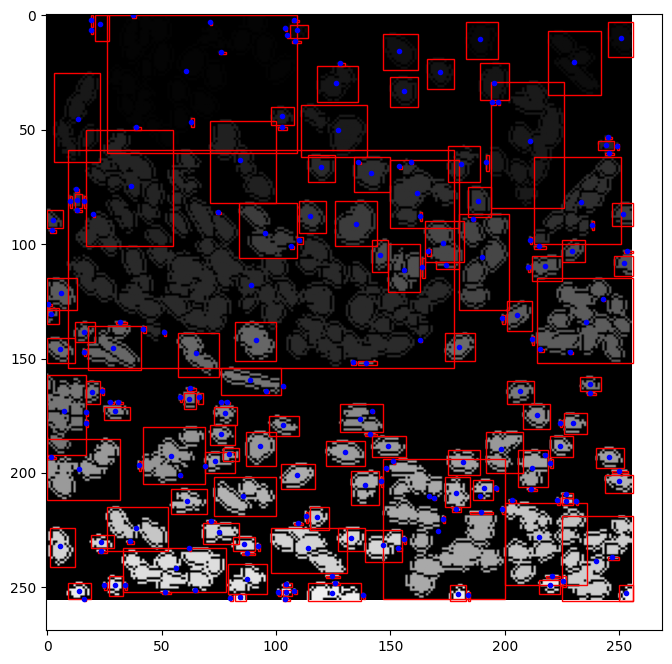

In [26]:
# 2. GRAFICO BOUNDING BOXES E CENTROIDS
fig, ax = plt.subplots(figsize=(8,8)) 
ax.imshow(inst_map, cmap="gray") #Carica la mappa dei nuclei come sfondo (GRIGIO)
for idx, nucleus_id in enumerate(nuclei_id): 
    x1, y1, x2, y2 = bboxs[idx] 
    cx, cy = centroids[idx]  
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=1, edgecolor="r", facecolor="none") 
    # la funzione rect in input riceve rispettivamente (punto di partenza, larghezza (x2-x1) e altezza (y2-y1)) 
    #edgecolor="r": r sta per Red (Rosso). Disegna il contorno.
    #facecolor="none" dice di non colorare l'interno del rettangolo
    ax.add_patch(rect)

    ax.plot(cx, cy, "bo", markersize=3) #bo": Sta per Blue Object ( cerchietto blu). ## densità nuclei

plt.show()



In [27]:
data_images = []

for img_path, mask_path in zip(image_paths, mask_paths):

    # RGB PER IMMAGINE
    img = np.array(Image.open(img_path))

    if img.ndim == 3:
        R = img[:,:,0].flatten()[::10]
        G = img[:,:,1].flatten()[::10]
        B = img[:,:,2].flatten()[::10]

        R_mean = np.mean(R)
        G_mean = np.mean(G)
        B_mean = np.mean(B)

        R_std = np.std(R)
        G_std = np.std(G)
        B_std = np.std(B)

    # NUCLEI E DENSITÀ

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    num_labels, _ = cv2.connectedComponents(binary)
    n_nuclei = num_labels - 1

    area = mask.shape[0] * mask.shape[1]
    density = n_nuclei / area

    # SALVA TUTTO
    
    data_images.append({
        "image_id": os.path.basename(img_path),
        "mask_id": os.path.basename(mask_path),
        "nuclei": n_nuclei,
        "density": density,
        "R_mean": R_mean,
        "G_mean": G_mean,
        "B_mean": B_mean,
        "R_std": R_std,
        "G_std": G_std,
        "B_std": B_std
    })

df_images = pd.DataFrame(data_images)

print(df_images.head())

                      image_id                       mask_id  nuclei  \
0  TCGA-G9-6348-01Z-00-DX1.tif  TCGA-21-5784-01Z-00-DX1 .png     307   
1  TCGA-CH-5767-01Z-00-DX1.tif  TCGA-18-5592-01Z-00-DX1 .png     195   
2  TCGA-G9-6336-01Z-00-DX1.tif  TCGA-CH-5767-01Z-00-DX1 .png     130   
3  TCGA-DK-A2I6-01A-01-TS1.tif  TCGA-AY-A8YK-01A-01-TS1 .png     224   
4  TCGA-HE-7130-01Z-00-DX1.tif  TCGA-G9-6336-01Z-00-DX1 .png     135   

    density     R_mean     G_mean     B_mean      R_std      G_std      B_std  
0  0.004684  206.41938  143.17374  181.72530  39.258356  46.852357  34.677216  
1  0.002975  203.10464  153.59585  185.44616  37.361292  49.249541  36.348621  
2  0.001984  195.93886  141.15037  177.11581  37.433321  44.676813  33.171150  
3  0.003418  136.31331   98.28093  139.23670  56.705531  65.875748  52.610394  
4  0.002060  169.77609   81.46946  126.25009  44.993581  34.472292  29.969716  


In [28]:
data_nuclei = []

for mask_path in mask_paths:
    labels = load_labels_from_png(mask_path)

    for i, nucleus_id in enumerate(labels["nuclei_id"]):
        bbox = labels["bboxs"][i]
        centroid = labels["centroids"][i]

        data_nuclei.append({
            "image_id": os.path.basename(mask_path),
            "nucleus_id": nucleus_id,
            "x_min": bbox[0],
            "y_min": bbox[1],
            "x_max": bbox[2],
            "y_max": bbox[3],
            "centroid_x": centroid[0],
            "centroid_y": centroid[1]
        })

df_nuclei = pd.DataFrame(data_nuclei)

print(df_nuclei.head())

                       image_id  nucleus_id  x_min  y_min  x_max  y_max  \
0  TCGA-21-5784-01Z-00-DX1 .png           1     19      0     20      5   
1  TCGA-21-5784-01Z-00-DX1 .png           2     21      0     27     11   
2  TCGA-21-5784-01Z-00-DX1 .png           3     37      0     39      1   
3  TCGA-21-5784-01Z-00-DX1 .png           4     26      0    109     60   
4  TCGA-21-5784-01Z-00-DX1 .png           5     71      3     72      4   

   centroid_x  centroid_y  
0   19.000000    2.000000  
1   23.068182    3.704545  
2   37.500000    0.000000  
3   60.522188   24.148936  
4   71.000000    3.000000  


In [29]:
df_dataset = pd.DataFrame([{
    "num_images": len(image_paths),
    "num_masks": len(mask_paths),
    "mean_nuclei_per_image": df_images["nuclei"].mean(),
    "mean_density": df_images["density"].mean(),
    "R_mean_dataset": df_images["R_mean"].mean(),
    "G_mean_dataset": df_images["G_mean"].mean(),
    "B_mean_dataset": df_images["B_mean"].mean()
}])

print(df_dataset)

   num_images  num_masks  mean_nuclei_per_image  mean_density  R_mean_dataset  \
0          82         82             167.134146       0.00255      190.774056   

   G_mean_dataset  B_mean_dataset  
0      159.649695      186.394195  


In [30]:
# NUMERI TOTALI NUCLEI E MEDIA NUCLEI PER IMMAGINE

print(f"Nuclei totali nel dataset:", df_images["nuclei"].sum())
print(f"Media di nuclei per immagine: ", df_images["nuclei"].mean() )

Nuclei totali nel dataset: 13705
Media di nuclei per immagine:  167.1341463414634


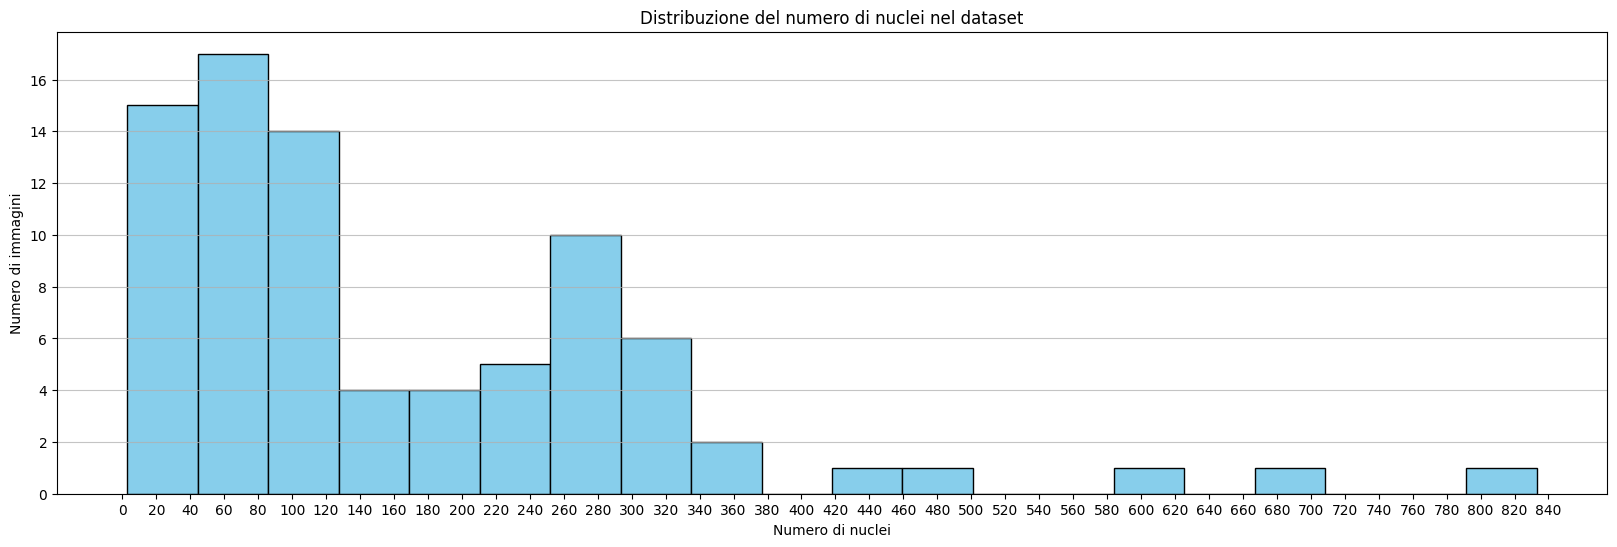

In [32]:
# GRAFICO DISTRIBUZIONE NUCLEI NELLE IMMAGINI

plt.figure(figsize=(20, 6))
plt.hist(df_images["nuclei"], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.xticks(np.arange(0, df_images["nuclei"].max() + 20, 20))
plt.grid(axis='y', alpha=0.75)
plt.savefig("hist_images_VS_nuclei_Pannuke.png", dpi=300)

plt.show() 

In [33]:
# DENSITà MEDIA E DEVIAZIONE STANDARD

print(f"densità media:", df_images["density"].mean())
print(f"deviazione standard: ", df_images["density"].std() )




densità media: 0.002550264684165396
deviazione standard:  0.0023892732341780627


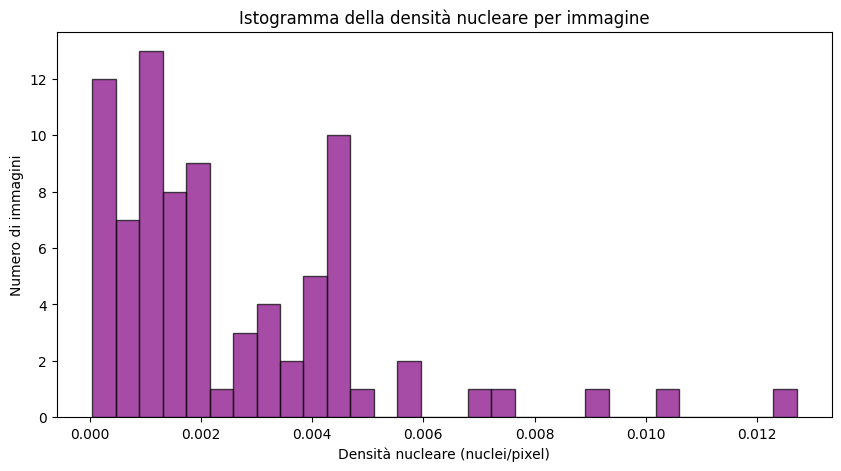

In [34]:
# ISOGRAMMA DENSITà NUCLEARE (NUCLEO/PIXEL)

plt.figure(figsize=(10,5))
plt.hist(df_images["density"], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.savefig("hist_images_VS_nuclei_density_Pannuke.png", dpi=300)

plt.show()

 TRAIN set:
Numero nuclei per immagine (prime 10): []
Densità media: nan
Deviazione standard: nan

 VALIDATE set:
Numero nuclei per immagine (prime 10): []
Densità media: nan
Deviazione standard: nan


/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


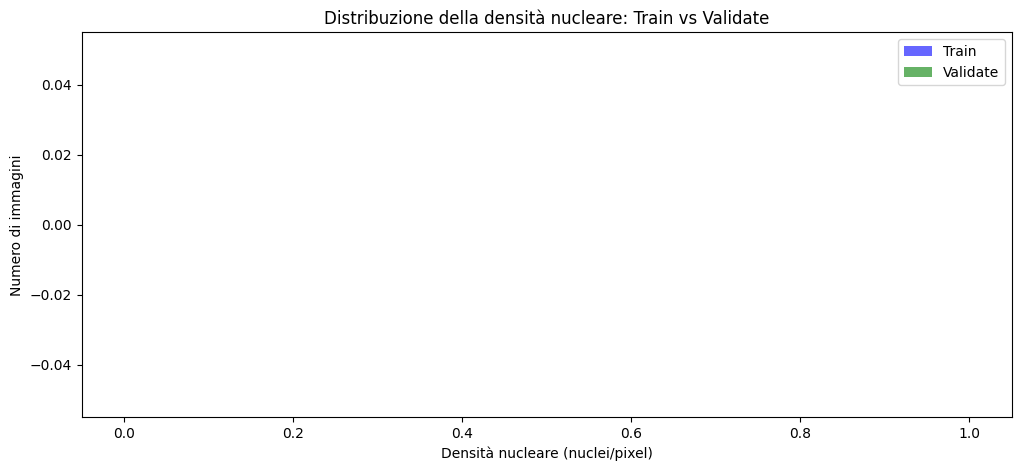

In [35]:
# Analisi separata TRAIN vs VALIDATE in base alla densità

train_masks = os.path.join(DATA_PATH, "train", "masks")
validate_masks = os.path.join(DATA_PATH, "validate", "masks")

def analyze_masks(mask_folder):
    mask_paths = glob.glob(os.path.join(mask_folder, "*.png"))
    nuclei_counts = []
    densities = []
    for mask_path in mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        num_labels, _ = cv2.connectedComponents(binary)
        nuclei_counts.append(num_labels - 1)
        area = mask.shape[0] * mask.shape[1]
        densities.append((num_labels - 1) / area)
    return nuclei_counts, densities

train_counts, train_densities = analyze_masks(train_masks)
validate_counts, validate_densities = analyze_masks(validate_masks)

print(" TRAIN set:")
print("Numero nuclei per immagine (prime 10):", train_counts[:10])
print("Densità media:", np.mean(train_densities))
print("Deviazione standard:", np.std(train_densities))

print("\n VALIDATE set:")
print("Numero nuclei per immagine (prime 10):", validate_counts[:10])
print("Densità media:", np.mean(validate_densities))
print("Deviazione standard:", np.std(validate_densities))

# Istogramma comparativo
plt.figure(figsize=(12,5))
plt.hist(train_densities, bins=30, alpha=0.6, label='Train', color='blue')
plt.hist(validate_densities, bins=30, alpha=0.6, label='Validate', color='green')
plt.title("Distribuzione della densità nucleare: Train vs Validate")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.legend()
plt.savefig("hist_images_VS_density_train_validate_Pannuke.png", dpi=300)

plt.show()

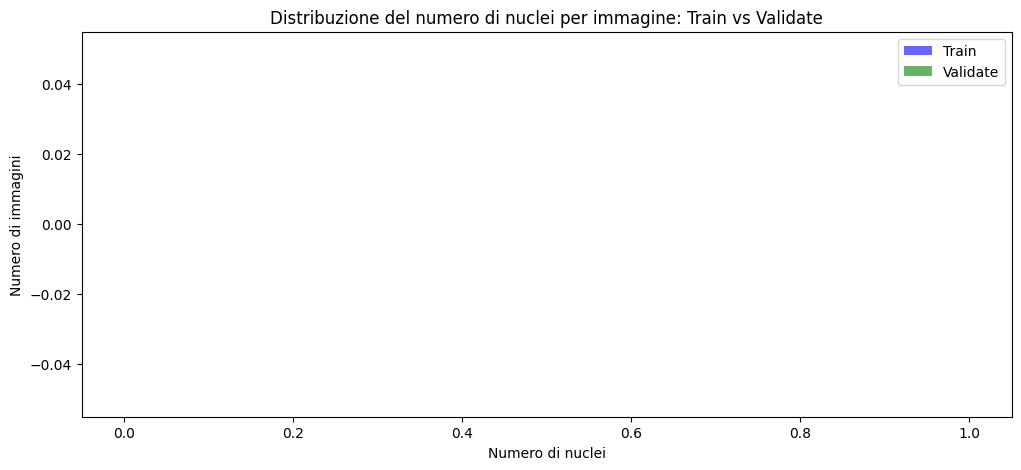

TRAIN:
Media nuclei: nan
Deviazione standard: nan

 VALIDATE:
Media nuclei: nan
Deviazione standard: nan


In [36]:
# Analisi separata TRAIN vs VALIDATE IN BASE AL NUMERO DI NUCLEI


plt.figure(figsize=(12,5))

plt.hist(train_counts, bins=30, alpha=0.6, label='Train', color='blue')
plt.hist(validate_counts, bins=30, alpha=0.6, label='Validate', color='green')

plt.title("Distribuzione del numero di nuclei per immagine: Train vs Validate")
plt.xlabel("Numero di nuclei")
plt.ylabel("Numero di immagini")
plt.legend()
plt.savefig("hist_images_VS_nuclei_train_validate_Pannuke.png", dpi=300)

plt.show()

# ----------------------------------------
# Statistiche
print("TRAIN:")
print("Media nuclei:", np.mean(train_counts))
print("Deviazione standard:", np.std(train_counts))

print("\n VALIDATE:")
print("Media nuclei:", np.mean(validate_counts))
print("Deviazione standard:", np.std(validate_counts))

/Users/silvia/FSL_Segmentation_Bio/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


(array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

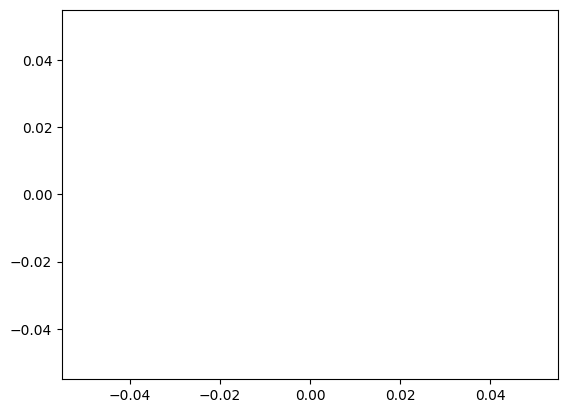

In [37]:
# CONFRONTO NORMALIZZATO 
plt.hist(train_counts, bins=30, alpha=0.5, density=True, label='Train')
plt.hist(validate_counts, bins=30, alpha=0.5, density=True, label='Validate')

In [38]:
# ANALISI RGB
image_paths = glob.glob(os.path.join(DATA_PATH, "train", "images", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "validate", "images", "*.png*"))

# array vuoti per ogni canale
R_values = []
G_values = []
B_values = []

# loop su tutte le immagini
for img_path in image_paths:
    img = Image.open(img_path)          # apri immagine
    img = np.array(img)                  # conversione in array numpy
    if img.ndim == 3:                    # RGB
        R_values.extend(img[:,:,0].flatten()[::10])
        G_values.extend(img[:,:,1].flatten()[::10])
        B_values.extend(img[:,:,2].flatten()[::10])

# Statistiche RGB

R_mean = np.mean(R_values)
G_mean = np.mean(G_values)
B_mean = np.mean(B_values)

R_std = np.std(R_values)
G_std = np.std(G_values)
B_std = np.std(B_values)

print("📊 STATISTICHE RGB\n")

print("🔴 Red  -> Media:", R_mean, " | Deviazione standard:", R_std)
print("🟢 Green-> Media:", G_mean, " | Deviazione standard:", G_std)
print("🔵 Blue -> Media:", B_mean, " | Deviazione standard:", B_std)

📊 STATISTICHE RGB

🔴 Red  -> Media: nan  | Deviazione standard: nan
🟢 Green-> Media: nan  | Deviazione standard: nan
🔵 Blue -> Media: nan  | Deviazione standard: nan


         R    G    B
count  0.0  0.0  0.0
mean   NaN  NaN  NaN
std    NaN  NaN  NaN
min    NaN  NaN  NaN
25%    NaN  NaN  NaN
50%    NaN  NaN  NaN
75%    NaN  NaN  NaN
max    NaN  NaN  NaN


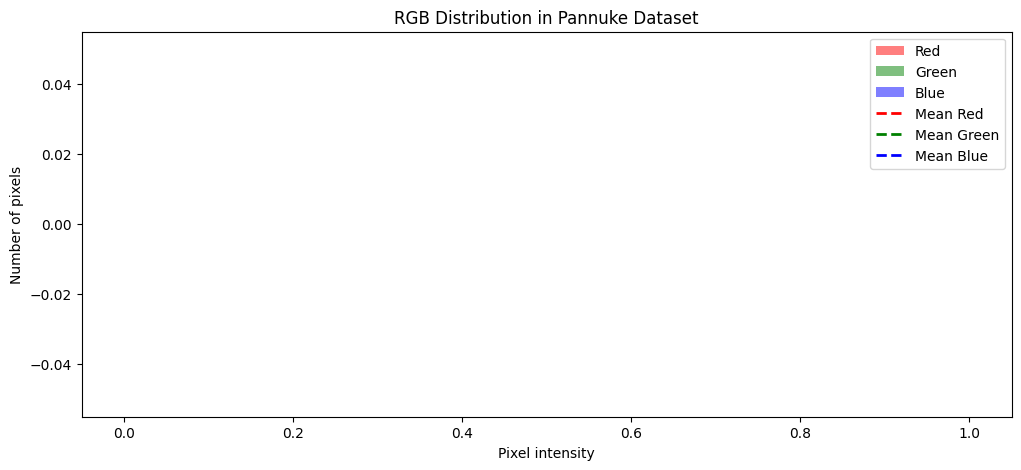

In [39]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.axvline(R_mean, color='red', linestyle='dashed', linewidth=2, label='Mean Red')
plt.axvline(G_mean, color='green', linestyle='dashed', linewidth=2, label='Mean Green')
plt.axvline(B_mean, color='blue', linestyle='dashed', linewidth=2, label='Mean Blue')


plt.title("RGB Distribution in Pannuke Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.savefig("RGB_distribuition_Pannuke.png", dpi=300)
plt.show()

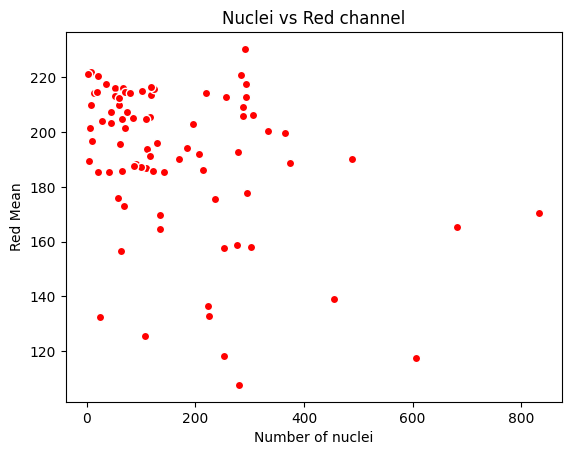

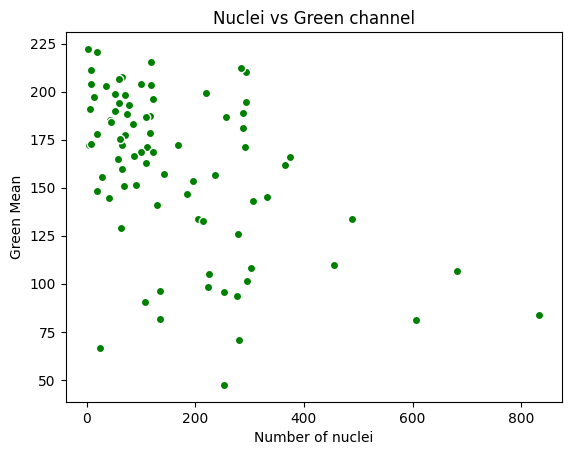

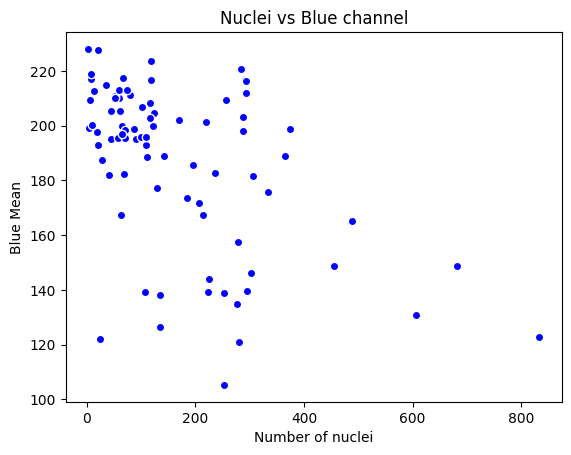

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_images["nuclei"], df_images["R_mean"], edgecolor='white', color= 'red')
plt.xlabel("Number of nuclei")
plt.ylabel("Red Mean")
plt.title("Nuclei vs Red channel")
plt.savefig("nuclei_VS_red_channel_Pannuke.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["G_mean"], edgecolor='white', color= 'green')
plt.xlabel("Number of nuclei")
plt.ylabel("Green Mean")
plt.title("Nuclei vs Green channel")
plt.savefig("nuclei_VS_green_channel_Pannuke.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["B_mean"], edgecolor='white', color= 'blue')
plt.xlabel("Number of nuclei")
plt.ylabel("Blue Mean")
plt.title("Nuclei vs Blue channel")
plt.savefig("nuclei_VS_blue_channel_Pannuke.png", dpi=300)
plt.show()

In [52]:
df_images.to_csv("df_images.csv", index=False)
df_nuclei.to_csv("df_nuclei.csv", index=False)
df_dataset.to_csv("df_dataset.csv", index=False)